### 랭체인 개요

랭체인은 LLM을 이용한 애플리케이션 개발 프레임워크이며, LLM을 이용한 다양한 종류의 애플리케이션에 사용할 수 있다.<br />
랭체인의 구현에는 파이썬과 자바스크립트/타입스크립트 두 가지가 있다.<br />
파이썬 구현이 더 활발하게 개발되고 있다.<br />

### 랭체인 사용 사례

하나는 LLM을 이용한 애플리케이션 개발에 필요한 구성 요소를 추상화된 모듈로 제공한다는 점<br />
하나는 특정 사용 사례에 특화된 기능을 제공한다는 점<br />

### LLM을 이용한 응용 프로그램으로는 다음과 같은 예를 들 수 있다.

* 제미나이처럼 대화할 수 있는 챗봇
* 문장 요약 도구
* 사내 문서 및 PDF 파일에 대한 Q&A 앱
* 나중에 설명할 'AI 에이전트'
<br />
랭체인은 위와 같이 LLM을 이용한 다양한 애플리케이션 구현에 사용할 수 있다. 

### 랭체인의 모듈

* Model I/O
	* Prompts
		* Prompt templates
		* Example selectors
	* Language models
		* LLMs
		* Chat models
	* Output parsers

* Data connection
	* Document loaders
	* Document transformers
		* Text splitters
		* Post retrieval
	* Text embedding models
	* Vector stores
	* Retrievers
* Chains
* Agents
	* Agent types
	* Tools
    	* Toolkits
* Memory
* Callbacks


### 랭체인 설치
재미나이라는 라이브러리도 함께 설치한다.<br />
이는 랭체인이 재미나이의 API를 호출하기 위해 내부적으로 재미나이 라이브러리를 사용하기 때문이다.<br />

In [2]:
!pip install -qU langchain-google-genai langchain


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Model I/O
### * Language models

* 랭체인의 Language models를 사용하면 다양한 언어 모델을 공통된 인터페이스로 사용할 수 있다
* 랭체인에서는 Language models를 크게 'LLMs'와 'Chat models' 두 가지로 분류하고 있다.

### 1. LLMs


'LLMs'는 하나의 텍스트 입력에 대해 하나의 텍스트 출력을 반환하는 전형적인 대규모 언어 모델을 다루는 모듈<BR />
Gemini의 구글 생성형 AI API를 랭체인에서 사용하려면 다음 예제와 같이 'GoogleGenerativeAI'라는 클래스를 사용<br />

In [3]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
# 1 API 키 설정
os.environ["GOOGLE_API_KEY"] = "your_api_key"
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0)
# 3 호출 및 결과 출력
result = llm.invoke("자기소개를 해주세요.")
print(result)

content='안녕하세요! 저는 여러분의 질문에 답하고 다양한 작업을 돕기 위해 만들어진 AI 어시스턴트입니다.\n\n**저의 역할은 다음과 같습니다:**\n\n*   **정보 제공:** 궁금한 점에 대해 정확하고 최신 정보를 찾아 알려드립니다.\n*   **아이디어 제안:** 글쓰기, 기획, 문제 해결 등 다양한 상황에서 아이디어를 얻는 데 도움을 드립니다.\n*   **콘텐츠 생성:** 글쓰기, 요약, 번역, 코딩 등 여러 형태의 텍스트 콘텐츠를 만들 수 있습니다.\n*   **학습 및 이해:** 방대한 양의 텍스트 데이터를 학습하여 자연어를 이해하고 생성하는 능력을 가지고 있습니다.\n\n저는 항상 친절하고 정확하게, 그리고 최대한 유용하게 답변을 드리기 위해 노력하고 있습니다. 궁금한 점이 있으시거나 도움이 필요하시면 언제든지 말씀해주세요! 😊' additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019f0beb-0138-7432-92c3-3747764bbf83-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 7, 'output_tokens': 1427, 'total_tokens': 1434, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 1237}}


사용자 Prompt <br />
      │<br />
      ▼<br />
ChatGoogleGenerativeAI (LLM)<br />
      │<br />
      ▼<br />
Gemini API<br />
      │<br />
      ▼<br />
응답

이 코드에서는 gemini-1.5-flash를 모델로 설정하고 temperature를 0으로 설정했다. temperature는 클수록 무작위적인 출력이, 작을수록 결정적인 출력이 나오는 파라미터이다. 이 장에서는 가능한 한 동일한 출력을 얻기 위해 temperature를 최솟값인 0으로 설정했다

 하나의 텍스트 입력에 대해 하나의 텍스트 출력을 반환하는 전형적인 대규모 언어 모델의 기초적인 예시로만 활용합니다

### 2. Chat Models
* 구글 Gemini의 최신 API 모델들은 단순히 하나의 텍스트를 입력하는 것이 아니라, 채팅 형식의 대화를 입력하면 응답을 받을 수 있도록 설계되어 있음
* 대화형 API 구조를 지원하기 위해 만들어진 랭체인의 모듈이 바로 'Chat models'임

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# 모델 이름 앞에 'models/'를 붙여서 명확하게 지정합니다.
# 현재 가장 추천되는 가성비 모델인 gemini-2.5-flash를 사용해 보세요!
chat = ChatGoogleGenerativeAI(model="models/gemini-2.5-flash", temperature=0)

messages = [
    SystemMessage(content="You are a helpful assistant."),
    HumanMessage(content="안녕하세요! 저는 존이라고 합니다!"),
    AIMessage(content="안녕하세요, 존 씨! 어떻게 도와드릴까요?"),
    HumanMessage(content="제 이름을 아세요?")
]

result = chat.invoke(messages)
print(result.content)

네, 존 씨라고 말씀해주셨습니다!


랭체인의 'SystemMessage', 'HumanMessage', 'AIMessage'는 각각 Chat Completions API의 "role": "system", "role": "user", "role": "assistant"에 대응한다. 
<br /> 따라서 앞의 코드에서 내부적으로는 다음과 같은 요청을 보내고 있다.

# Callback을 이용한 스트리밍

LLM을 이용한 애플리케이션을 구현할 때 UX(사용자 경험, User Experience)를 개선하기 위해 응답을 스트리밍으로 받고 싶은 경우가 많을 것이다.<br />
랭체인에서는 Callback 기능을 통해 Gemini API의 응답을 스트리밍으로 처리할 수 있다.
예를 들어, 랭체인에서 제공하는 StreamingStdOutCallbackHandler를 ChatGoogleGenerativeAI로 설정하면 생성된 텍스트가 스트리밍으로 표준 출력에 표시됨

In [8]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.callbacks import StreamingStdOutCallbackHandler
from langchain_core.messages import HumanMessage

# api_key 파라미터에 발급받은 키를 직접 문자열로 넣습니다.
chat = ChatGoogleGenerativeAI(
    model="models/gemini-2.5-flash", 
    api_key="your_api_key",  # 여기에 발급받은 실제 API 키를 입력하세요
    temperature=0,
    streaming=True,
    callbacks=[StreamingStdOutCallbackHandler()]
)

messages = [
    HumanMessage(content="맛있는 김치찌개를 끓이는 비법을 단계별로 자세히 알려줘!")
]

chat.invoke(messages)

맛있는 김치찌개는 단순히 재료를 넣고 끓이는 것을 넘어, 몇 가지 비법이 숨어있답니다! 깊고 진한 국물 맛을 내는 단계별 비법을 자세히 알려드릴게요.

---

## 🍲 깊고 진한 맛! 김치찌개 황금 레시피 (비법 대방출)

### ✨ 맛있는 김치찌개의 핵심 비법 요약

1.  **잘 익은 신김치 사용:** 김치찌개의 8할은 김치! 푹 익어 신맛이 나는 김치가 깊은 맛을 냅니다.
2.  **돼지고기 볶기:** 돼지고기를 먼저 볶아 기름을 내고 고소한 맛을 끌어올립니다.
3.  **김치와 양념 볶기:** 김치를 양념과 함께 충분히 볶아 김치의 깊은 맛을 응축시킵니다.
4.  **육수 사용:** 맹물 대신 멸치 다시마 육수나 쌀뜨물을 사용해 감칠맛을 더합니다.
5.  **충분한 끓임 시간:** 약불에서 오래 끓여 재료들의 맛이 충분히 우러나오게 합니다.

---

### 📝 재료 준비 (2-3인분 기준)

**[주재료]**
*   **신김치:** 1/4포기 (약 400-500g) - **가장 중요!**
*   **돼지고기:** 찌개용 (목살, 앞다리살, 삼겹살 등) 200-300g - 비계가 적당히 있는 부위가 좋습니다.
*   **두부:** 1/2모 (약 150g)
*   **양파:** 1/2개
*   **대파:** 1/2대
*   **청양고추 (선택):** 1개 (칼칼한 맛 선호 시)
*   **김치 국물:** 1/2컵 (약 100ml)
*   **육수:** 멸치 다시마 육수 또는 쌀뜨물 700-800ml (맹물도 가능하나 육수가 훨씬 맛있어요!)

**[양념]**
*   **고춧가루:** 2-3큰술 (김치 색깔과 매운 정도에 따라 조절)
*   **고추장:** 1/2-1큰술 (선택 사항, 깊은 맛을 더하고 싶을 때)
*   **국간장 (또는 진간장):** 1-2큰술 (간 조절용)
*   **다진 마늘:** 1큰술
*   **설탕 (또는 매실액):** 1/2-1큰술 (신김치의 신맛을 중화하고 감칠맛을 줍니다)
*   **참기름 (선택):** 1/2큰술 (김치 

AIMessage(content='맛있는 김치찌개는 단순히 재료를 넣고 끓이는 것을 넘어, 몇 가지 비법이 숨어있답니다! 깊고 진한 국물 맛을 내는 단계별 비법을 자세히 알려드릴게요.\n\n---\n\n## 🍲 깊고 진한 맛! 김치찌개 황금 레시피 (비법 대방출)\n\n### ✨ 맛있는 김치찌개의 핵심 비법 요약\n\n1.  **잘 익은 신김치 사용:** 김치찌개의 8할은 김치! 푹 익어 신맛이 나는 김치가 깊은 맛을 냅니다.\n2.  **돼지고기 볶기:** 돼지고기를 먼저 볶아 기름을 내고 고소한 맛을 끌어올립니다.\n3.  **김치와 양념 볶기:** 김치를 양념과 함께 충분히 볶아 김치의 깊은 맛을 응축시킵니다.\n4.  **육수 사용:** 맹물 대신 멸치 다시마 육수나 쌀뜨물을 사용해 감칠맛을 더합니다.\n5.  **충분한 끓임 시간:** 약불에서 오래 끓여 재료들의 맛이 충분히 우러나오게 합니다.\n\n---\n\n### 📝 재료 준비 (2-3인분 기준)\n\n**[주재료]**\n*   **신김치:** 1/4포기 (약 400-500g) - **가장 중요!**\n*   **돼지고기:** 찌개용 (목살, 앞다리살, 삼겹살 등) 200-300g - 비계가 적당히 있는 부위가 좋습니다.\n*   **두부:** 1/2모 (약 150g)\n*   **양파:** 1/2개\n*   **대파:** 1/2대\n*   **청양고추 (선택):** 1개 (칼칼한 맛 선호 시)\n*   **김치 국물:** 1/2컵 (약 100ml)\n*   **육수:** 멸치 다시마 육수 또는 쌀뜨물 700-800ml (맹물도 가능하나 육수가 훨씬 맛있어요!)\n\n**[양념]**\n*   **고춧가루:** 2-3큰술 (김치 색깔과 매운 정도에 따라 조절)\n*   **고추장:** 1/2-1큰술 (선택 사항, 깊은 맛을 더하고 싶을 때)\n*   **국간장 (또는 진간장):** 1-2큰술 (간 조절용)\n*   **다진 마늘:** 1큰술\n*   **설탕 (또는 매실액):** 1/2-1큰술 (

랭체인의 Callback 기능은 앞서 언급한 StreamingStdOutCallbackHandler와 같이 공식적으로 제공되는 CallbackHandler를 사용할 수도 있음<br /> 
사용자가 직접 커스텀 CallbackHandler를 구현하여 사용할 수도 있음

In [9]:
from langchain_core.callbacks import BaseCallbackHandler
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

# 1. BaseCallbackHandler를 상속받아 커스텀 콜백 핸들러 정의
class GeminiCustomCallbackHandler(BaseCallbackHandler):
    def on_llm_start(self, serialized, prompts, **kwargs):
        print("[이벤트] Gemini가 답변 생성을 시작합니다...\n")

    def on_llm_new_token(self, token: str, **kwargs) -> None:
        # 실시간으로 생성되는 토큰(단어 조각)을 가공하거나 모니터링할 수 있습니다.
        # 여기서는 토큰 사이에 대시(-)를 넣어 구별해 봅니다.
        print(f"{token}", end="-", flush=True)

    def on_llm_end(self, response, **kwargs):
        print("\n\n [이벤트] Gemini가 답변 생성을 완료했습니다.")

# 2. 모델 생성 및 커스텀 콜백 등록
chat = ChatGoogleGenerativeAI(
    model="models/gemini-2.5-flash",
    temperature=0,
    streaming=True, # 토큰 단위 이벤트를 잡으려면 streaming=True가 필수입니다.
    callbacks=[GeminiCustomCallbackHandler()] # 여기에 커스텀 콜백 등록
)

messages = [HumanMessage(content="'인공지능'으로 삼행시 지어줘.")]
chat.invoke(messages)

[이벤트] Gemini가 답변 생성을 시작합니다...

네, '인공지능'으로 삼행시 지어볼게요!

**인**류의 삶을 혁신하는 힘,
**공**부하고 생각하며 발전하는,
**지능**으로 우리의 미래를- 밝히네.--

 [이벤트] Gemini가 답변 생성을 완료했습니다.


AIMessage(content="네, '인공지능'으로 삼행시 지어볼게요!\n\n**인**류의 삶을 혁신하는 힘,\n**공**부하고 생각하며 발전하는,\n**지능**으로 우리의 미래를 밝히네.", additional_kwargs={}, response_metadata={'safety_ratings': [], 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'model_provider': 'google_genai'}, id='lc_run--019f0c20-6b1b-7f71-abc4-c18611dfcf57', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 1361, 'total_tokens': 1376, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 1307}})

커스텀 CallbackHandler를 사용하면 Gemini 모델의 처리 시작(on_llm_start), 새로운 토큰 생성(on_llm_new_token), 모델의 처리 종료(on_llm_end) 등의 핵심 이벤트 타이밍에 맞춰 데이터베이스 저장, UI 업데이트, 로그 기록 등 임의의 처리를 자유롭게 실행할 수 있다

### * Prompts

### 1. PromptTemplate<br />
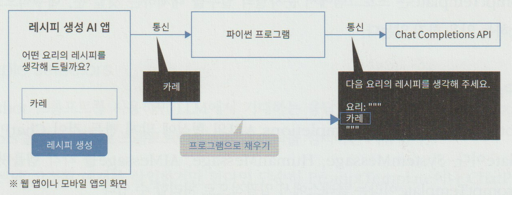<br />
PromptTemplate을 사용하면 프롬프트의 고정된 문자열 템플릿 속에 동적으로 변경될 변수(중괄호 { })를 정의할 수 있다. <br />
이를 통해 사용자 입력에 따라 유연하게 프롬프트를 생성하고 Gemini 모델에 전달할 수 있다.

In [12]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
# 1 API 키 설정
os.environ["GOOGLE_API_KEY"] = "your_api_key"
# 2해결의 열쇠: 모델명을 gemini-2.5-flash로 변경합니다.
# 내부 주소 매핑 오류(404)를 완전히 우회하는 가장 확실한 방법입니다.
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0)


from langchain_core.prompts import PromptTemplate
# 1. 템플릿 모양 정의 (변수는 중괄호 {}로 감싸줍니다)
template = """
다음 요리의 레시피를 생각해 주세요.

요리: {dish}
"""

# 2. PromptTemplate 객체 생성
prompt = PromptTemplate(
    input_variables=["dish"],
    template=template,
)

# 3. format 메서드를 사용해 변수에 실제 값("카레")을 주입
formatted_prompt = prompt.format(dish="카레")
print("--- 생성된 프롬프트 ---")
print(formatted_prompt)
response = llm.invoke(formatted_prompt)
print(response)

--- 생성된 프롬프트 ---

다음 요리의 레시피를 생각해 주세요.

요리: 카레

content='집에서 쉽고 맛있게 만들 수 있는 \'푸짐한 닭고기 카레\' 레시피를 알려드릴게요. 남녀노소 누구나 좋아하는 익숙한 맛으로 준비했습니다!\n\n---\n\n## 🍛 푸짐한 닭고기 카레 레시피\n\n**"따뜻한 밥 위에 듬뿍 얹어 먹으면 든든하고 맛있는, 온 가족이 좋아하는 집밥 카레!"**\n\n*   **난이도:** 하\n*   **조리 시간:** 30분\n*   **분량:** 3-4인분\n\n---\n\n### 📝 재료\n\n**[주재료]**\n*   닭고기 (닭다리살 또는 닭가슴살) 300-400g\n*   감자 2개 (중간 크기)\n*   당근 1개 (중간 크기)\n*   양파 1개 (중간 크기)\n*   애호박 1/2개 (선택 사항, 넣으면 더 맛있어요!)\n*   시판 카레 가루 100g (또는 고형 카레 1팩)\n*   물 600-700ml (카레 가루 제품 설명서 참고)\n\n**[양념 및 기타]**\n*   식용유 2-3큰술\n*   소금 약간\n*   후추 약간\n*   (선택 사항) 다진 마늘 1큰술\n*   (선택 사항) 우유 또는 생크림 50ml (마지막에 넣으면 부드러워져요)\n\n---\n\n### 👩\u200d🍳 조리 과정\n\n1.  **재료 준비:**\n    *   닭고기는 한 입 크기로 썰어 소금, 후추로 밑간을 해둡니다.\n    *   감자, 당근, 양파, 애호박은 껍질을 벗기고 닭고기와 비슷한 크기로 깍둑썰기 합니다.\n    *   카레 가루는 찬물 100ml 정도에 미리 풀어두면 뭉치지 않고 좋습니다. (고형 카레는 이 과정 생략)\n\n2.  **재료 볶기:**\n    *   깊은 냄비나 팬에 식용유를 두르고 중불로 달굽니다.\n    *   양파를 먼저 넣고 투명해질 때까지 볶아줍니다. (다진 마늘을 넣는다면 이때 함께 볶아 향을 내주세요.)\n    *   양파가 투명해지면 밑간한 닭고기를 넣고 겉면이 노릇하

PromptTemplate의 format 메서드를 통해 템플릿의 {dish} 부분이 '카레'로 대체됐다.<br />
참고로 PromptTemplate은 프로그램에서 문자열의 일부를 대체하는 것일 뿐, 내부적으로 LLM을 호출하는 일은 하지 않는다.

In [6]:
from langchain_core.prompts import PromptTemplate

# 1. 템플릿 정의 (변수는 {category}와 {text} 두 개)
template = "{category}에 대해 설명해 주세요. 오늘의 주제는 {text}입니다."

# 2. partial_variables를 사용해 category만 먼저 채운 템플릿 생성
partial_prompt = PromptTemplate(
    template=template, 
    input_variables=["text"], # 최종적으로 입력받을 변수
    partial_variables={"category": "인공지능"} # 미리 채워둘 변수
)

# 3. 나중에 필요한 'text'만 넣어서 프롬프트 완성!
final_prompt = partial_prompt.format(text="임베딩 기술")
print(final_prompt)
# 출력: 인공지능에 대해 설명해 주세요. 오늘의 주제는 임베딩 기술입니다.

인공지능에 대해 설명해 주세요. 오늘의 주제는 임베딩 기술입니다.


### 2. ChatPromptTemplate
PromptTemplate을 Chat API의 형식(메시지 배열)에 맞게 확장한 것이 바로 ChatPromptTemplate이다.<br />

Gemini와 같은 대화형 모델은 시스템 메시지(SystemMessage), 사용자 메시지(HumanMessage), AI 응답 메시지(AIMessage)가 차례대로 쌓인 대화 기록을 입력받는다.<br />
ChatPromptTemplate 클래스를 사용하면 각 메시지 역할을 개별적으로 템플릿화하여 일괄적으로 관리하고, 변수를 한 번에 주입하여 대화형 프롬프트를 쉽게 생성할 수 있다.<br />

In [9]:
from langchain_core.prompts import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
)

# 1. 각 메시지 역할별 템플릿 클래스를 명시적으로 생성하여 리스트로 묶어줍니다.
# (원본 코드의 괄호 닫힘 오타를 수정했습니다.)
chat_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template("당신은 {country} 요리 전문가입니다."),
    HumanMessagePromptTemplate.from_template("다음 요리의 레시피를 생각해 주세요.\n\n요리: {dish}")
])

# 2. 변수를 주입하고 랭체인 메시지 객체 리스트로 변환합니다.
messages = chat_prompt.format_prompt(country="일본", dish="고기감자조림(니쿠자가)").to_messages()

# 3. 생성된 메시지 리스트 확인
print("--- 생성된 메시지 리스트 ---")
print(messages)

--- 생성된 메시지 리스트 ---
[SystemMessage(content='당신은 일본 요리 전문가입니다.', additional_kwargs={}, response_metadata={}), HumanMessage(content='다음 요리의 레시피를 생각해 주세요.\n\n요리: 고기감자조림(니쿠자가)', additional_kwargs={}, response_metadata={})]


### 3. Example selectors
Few-shot은 LLM에게 "눈치껏 이렇게 대답해라" 하고 예시를 미리 보여주는 기술입니다.<br />
하지만 매번 똑같은 예시를 고정으로 넣어두면 비효율적이니, 'Example Selector(예시 선택기)'라는 똑똑한 매니저를 두는 것입니다.<br /> 
이 매니저의 역할은 딱 두 가지입니다.<br />
- 글자 수 눈치껏 조절하기 (비용 및 용량 절감)사용자가 질문을 짧게 하면 rightarrow 힌트(예시)를 넉넉하게 3~4개 많이 넣어줍니다.<br />
사용자가 질문을 길게 하면 rightarrow 프롬프트 용량이 넘치지 않게 예시를 1개로 줄이거나 빼버립니다.<br />
- 질문에 딱 맞는 맞춤형 힌트 골라주기 (의미론적 매칭)사용자가 "포도"를 물어보면 rightarrow 족보(예시) 뒤져서 가장 비슷한 "사과, 바나나" 예시를 자동으로 꽂아줍니다.<br />
사용자가 "배트맨"을 물어보면 rightarrow 자동으로 "아이언맨" 같은 캐릭터 예시로 싹 바꿔줍니다.<br />
<br />
Example Selector는 모든 예시를 무식하게 다 집어넣는 게 아니라, 내 질문의 “길이와 종류에 맞춰 실시간으로 가장 유용한 힌트만 골라주는 '스마트 요약 필터'”입니다.<br />

In [14]:
!pip install -qU sentence-transformers

In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer

# 1. 로컬 CPU 기반 초경량 임베딩 모델 로드
local_model = SentenceTransformer("all-MiniLM-L6-v2")

# 2. Few-shot 예제 데이터셋 정의
examples = [
    {"input": "사과", "output": "과일 - 빨갛고 아삭한 식감이 특징입니다."},
    {"input": "바나나", "output": "과일 - 노랗고 부드러우며 달콤합니다."},
    {"input": "아이언맨", "output": "영화 캐릭터 - 마블 시네마틱 유니버스의 히어로입니다."},
    {"input": "배트맨", "output": "영화 캐릭터 - DC 코믹스의 어둠의 기사입니다."},
]

# 3. 예제 입력 데이터들의 임베딩 미리 계산
ex_inputs = [ex["input"] for ex in examples]
ex_embeddings = local_model.encode(ex_inputs)

# 4. 테스트할 입력 단어 설정
word = "슈퍼맨"

# 5. 입력 단어의 임베딩 추출 및 유사도 계산
query_emb = local_model.encode(word)

# 각 예제와의 코사인 유사도 연산
similarities = [
    np.dot(query_emb, ex_emb) / (np.linalg.norm(query_emb) * np.linalg.norm(ex_emb)) 
    for ex_emb in ex_embeddings
]

# 가장 유사도가 높은 예제의 인덱스 추출 (k=1 Semantic Similarity Selector 역할)
best_idx = np.argmax(similarities)
best_ex = examples[best_idx]

# 6. FewShotPromptTemplate 형태의 동적 프롬프트 조립
prefix = "주어진 단어의 카테고리와 특징을 한 줄로 설명하세요.\n\n"
example_part = f"입력: {best_ex['input']}\n출력: {best_ex['output']}\n\n"
suffix = f"입력: {word}\n출력:"

formatted_prompt = prefix + example_part + suffix

# 7. 최종 결과 출력
print("\n--- [테스트] '슈퍼맨' 입력 시 생성되는 프롬프트 ---")
print(formatted_prompt)

In [16]:
## Gyan.FFmpeg오류가 생기는 경우
!pip uninstall torchcodec -y

Found existing installation: torchcodec 0.14.0
Uninstalling torchcodec-0.14.0:
  Successfully uninstalled torchcodec-0.14.0
Note: you may need to restart the kernel to use updated packages.


### Output parsers
LLM이 특정 형식으로 출력하도록 하고, 그 출력을 프로그래밍 방식으로 처리하고 싶을 때가 있다.<br />
이때 사용할 수 있는 것이 ‘Output Parsers’다.<br />
<br />
Output parsers 개요<br />
<br /> 
프롬프트 주입 (Format Instructions)<br />
LLM에게 "구조화된 형태로 답변해줘"라고 인간의 언어로 일일이 지시하는 것은 번거롭고 실수하기 쉽습니다.<br />
Output Parser는 LLM이 이해할 수 있는 최적의 출력 형식 지시문(Format Instructions)을 자동으로 생성하여 프롬프트에 내장시켜 줍니다.<br />
<br />
예시: "반드시 key값으로 'name'과 'age'를 가진 JSON 형식으로 답변하고, 앞뒤에 불필요한 설명은 붙이지 마."<br />
<br />
응답 파싱 및 객체화 (Parsing)<br />
LLM이 내뱉은 텍스트(String) 응답을 받아, 지정된 데이터 구조로 파싱합니다.<br />
이 과정에서 텍스트가 Python의 dict나 Pydantic 모델로 변환되어, 이후 코드에서 response.name처럼 프로그래밍 방식으로 즉시 활용할 수 있게 됩니다.<br />
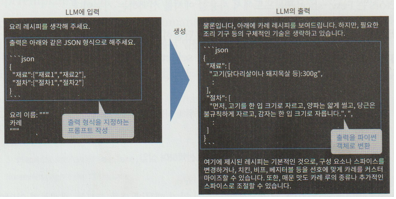


PydanticOutputParser를 이용해 Python 객체 가져오기

랭체인(LangChain)의 출력 파서 중 하나인 PydanticOutputParser를 사용하면, LLM의 답변을 Python 객체 형태로 손쉽게 가져올 수 있습니다. <br />
여기서는 PydanticOutputParser를 활용해 LLM이 생성한 요리 레시피 텍스트를 Recipe 클래스의 인스턴스로 자동 변환하는 예제를 살펴보겠습니다.<br />
먼저, LLM이 출력할 데이터 구조인 ‘재료 목록(ingredients)’과 ‘조리 단계(steps)’를 필드로 가지는 Recipe 클래스를 Pydantic 모델로 정의합니다.

In [2]:
from pydantic import BaseModel, Field

class Recipe(BaseModel):
    ingredients: list[str] = Field(description="ingredients of the dish")
    steps: list[str] = Field(description="steps to make the dish")

이 Recipe 클래스를 주고 PydanticOutputParser를 생성한다.

In [3]:
from langchain_core.output_parsers import PydanticOutputParser
parser = PydanticOutputParser(pydantic_object=Recipe)

그리고 PydanticOutputParser에서 프롬프트에 포함할 출력 형식의 설명문을 생성한다.

In [4]:
format_instructions = parser.get_format_instructions() # "JSON 형태로 출력되도록 만드는 핵심 핵심 코드"

여기서 생성한 format_instructions는 Recipe 클래스에 대응하는 출력 형식을 지정하는 문자열이며, format_instructions를 print로 표시하면 다음과 같다.

In [5]:
print(format_instructions)

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"ingredients": {"description": "ingredients of the dish", "items": {"type": "string"}, "title": "Ingredients", "type": "array"}, "steps": {"description": "steps to make the dish", "items": {"type": "string"}, "title": "Steps", "type": "array"}}, "required": ["ingredients", "steps"]}
```


출력을 JSON 형식으로 해 주세요’라는 내용이다. 이 `format_instructions`를 프롬프트에 삽입해 LLM이 이 형식에 따른 응답을 반환하도록 한다.<br />
이어서 `format_instructions`를 사용해 `PromptTemplate`을 생성한다.

In [13]:
from langchain_core.prompts import PromptTemplate

template = """다음 요리의 레시피를 생각해 주세요.

{format_instructions}

요리: {dish}
"""

prompt = PromptTemplate(
    template=template,
    input_variables=["dish"],
    partial_variables={"format_instructions": format_instructions}
)

In [14]:
formatted_prompt = prompt.format(dish="카레")
print(formatted_prompt)

다음 요리의 레시피를 생각해 주세요.

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"ingredients": {"description": "ingredients of the dish", "items": {"type": "string"}, "title": "Ingredients", "type": "array"}, "steps": {"description": "steps to make the dish", "items": {"type": "string"}, "title": "Steps", "type": "array"}}, "required": ["ingredients", "steps"]}
```

요리: 카레



In [15]:
!pip install -qU langchain-google-genai

<class '__main__.Recipe'>

--- ingredients ---
['잘 익은 김치 300g (썰어서 준비)', '돼지고기 (목살 또는 삼겹살) 200g (한입 크기로 썰기)', '두부 1/2모 (깍둑썰기)', '양파 1/2개 (채 썰기)', '대파 1/2대 (어슷썰기)', '청양고추 1개 (어슷썰기, 선택 사항)', '다진 마늘 1큰술', '고춧가루 1큰술', '국간장 1큰술 (또는 멸치액젓)', '설탕 1/2작은술', '참기름 1큰술', '멸치 육수 또는 쌀뜨물 600ml']

--- steps ---
['냄비에 참기름을 두르고 돼지고기를 넣어 볶다가 고기가 익으면 썰어둔 김치를 넣고 2-3분간 더 볶습니다.', '다진 마늘, 고춧가루, 설탕을 넣고 김치와 함께 1분 정도 더 볶아줍니다.', '멸치 육수 또는 쌀뜨물을 붓고 끓기 시작하면 중불로 줄여 10분 정도 끓입니다.', '양파, 두부, 청양고추를 넣고 5분 정도 더 끓입니다.', '국간장으로 간을 맞추고, 마지막으로 대파를 넣고 한소끔 더 끓인 후 불을 끕니다.', '따뜻한 밥과 함께 맛있게 즐기세요.']

--- 순수 JSON 출력 ---
{
  "ingredients": [
    "잘 익은 김치 300g (썰어서 준비)",
    "돼지고기 (목살 또는 삼겹살) 200g (한입 크기로 썰기)",
    "두부 1/2모 (깍둑썰기)",
    "양파 1/2개 (채 썰기)",
    "대파 1/2대 (어슷썰기)",
    "청양고추 1개 (어슷썰기, 선택 사항)",
    "다진 마늘 1큰술",
    "고춧가루 1큰술",
    "국간장 1큰술 (또는 멸치액젓)",
    "설탕 1/2작은술",
    "참기름 1큰술",
    "멸치 육수 또는 쌀뜨물 600ml"
  ],
  "steps": [
    "냄비에 참기름을 두르고 돼지고기를 넣어 볶다가 고기가 익으면 썰어둔 김치를 넣고 2-3분간 더 볶습니다.",
    "다진 마늘, 고춧가루, 설탕을 넣고 김치와 함께 1분 정도

In [2]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
# HumanMessage 클래스를 가져옵니다.
from langchain_core.messages import HumanMessage

load_dotenv()

# 1. 데이터 구조 정의
class Recipe(BaseModel):
    ingredients: list[str] = Field(description="ingredients of the dish")
    steps: list[str] = Field(description="steps to make the dish")

# 2. 파서 및 지시문 준비
parser = PydanticOutputParser(pydantic_object=Recipe)
format_instructions = parser.get_format_instructions()

# 3. 프롬프트 템플릿 완성
prompt_template = PromptTemplate(
    template="지정된 요리에 대한 레시피를 만들어주세요.\n\n{format_instructions}\n\n요리명: {dish}",
    input_variables=["dish"],
    partial_variables={"format_instructions": format_instructions}
)

# 4. 프롬프트를 실제 텍스트로 변환 (이 값이formatted_prompt가 됩니다)
formatted_prompt = prompt_template.format(dish="김치찌개")

# 5. 모델 선언
chat = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

# 6. 메시지 가방에 편지 담기
messages = [HumanMessage(content=formatted_prompt)]

# 7. 제미나이에게 실행 명령 내리기
output = chat.invoke(messages)

# 8. 결과 텍스트 출력
print("--- 제미나이의 원본 답변 (JSON 텍스트) ---")
print(output.content)6

# 9. 마지막으로 텍스트를 파이썬 객체로 최종 변환
final_recipe = parser.parse(output.content)

print("\n--- 파싱된 결과 객체 확인 ---")
print(final_recipe.ingredients)

--- 제미나이의 원본 답변 (JSON 텍스트) ---
```json
{
  "ingredients": [
    "잘 익은 김치 300g (한입 크기로 썰기)",
    "돼지고기 (목살 또는 삼겹살) 200g (한입 크기로 썰기)",
    "두부 1/2모 (깍둑썰기 또는 도톰하게 썰기)",
    "양파 1/2개 (채 썰기)",
    "대파 1/2대 (어슷 썰기)",
    "청양고추 1개 (선택 사항, 어슷 썰기)",
    "다진 마늘 1큰술",
    "고춧가루 1큰술 (기호에 따라 조절)",
    "국간장 1큰술 (또는 멸치액젓)",
    "설탕 1/2작은술 (김치의 신맛을 중화)",
    "참기름 1큰술",
    "쌀뜨물 또는 멸치 다시마 육수 500ml (또는 물)",
    "소금 약간 (간 조절용)"
  ],
  "steps": [
    "냄비에 참기름을 두르고 돼지고기를 넣어 겉면이 노릇해질 때까지 볶습니다.",
    "돼지고기가 어느 정도 익으면 썰어둔 김치를 넣고 2-3분간 함께 볶습니다.",
    "다진 마늘, 고춧가루, 설탕을 넣고 1분 정도 더 볶아줍니다.",
    "쌀뜨물 또는 육수를 붓고 센 불에서 끓입니다. 끓어오르면 중불로 줄여 10-15분간 끓여 돼지고기와 김치가 부드러워지도록 합니다.",
    "양파, 두부, 대파, 청양고추(선택 사항)를 넣고 5분 정도 더 끓입니다.",
    "국간장으로 간을 맞추고, 필요하면 소금을 추가하여 최종 간을 조절합니다.",
    "모든 재료가 잘 익고 맛이 어우러지면 불을 끄고 따뜻한 밥과 함께 냅니다."
  ]
}
```

--- 파싱된 결과 객체 확인 ---
['잘 익은 김치 300g (한입 크기로 썰기)', '돼지고기 (목살 또는 삼겹살) 200g (한입 크기로 썰기)', '두부 1/2모 (깍둑썰기 또는 도톰하게 썰기)', '양파 1/2개 (채 썰기)', '대파 1/2대 (어슷 썰기)', '청양고추 1개 (선택 사항, 어슷 썰기)', '다진 마늘 1큰술', '고

 이 응답을 파이썬의 타입 어노테이션(Type Annotations)을 활용하여 데이터의 유효성을 검증(Validation)하고 파싱(Parsing)하는 가장 인기 있는 파이썬 라이브러리 중 하나 Pydantic의 클래스로 변환하여 사용하고 싶을 때가 많다. 
`PydanticOutputParser`를 사용하면 그 변환 과정도 간단하다.

In [3]:
clean_text = output.content if isinstance(output.content, str) else output.content[0]['text']

# 이제 깨끗해진 텍스트를 파서에게 넘겨줍니다!
recipe = parser.parse(clean_text)

print(type(recipe))
print(recipe)

<class '__main__.Recipe'>
ingredients=['잘 익은 김치 300g (한입 크기로 썰기)', '돼지고기 (목살 또는 삼겹살) 200g (한입 크기로 썰기)', '두부 1/2모 (깍둑썰기 또는 도톰하게 썰기)', '양파 1/2개 (채 썰기)', '대파 1/2대 (어슷 썰기)', '청양고추 1개 (선택 사항, 어슷 썰기)', '다진 마늘 1큰술', '고춧가루 1큰술 (기호에 따라 조절)', '국간장 1큰술 (또는 멸치액젓)', '설탕 1/2작은술 (김치의 신맛을 중화)', '참기름 1큰술', '쌀뜨물 또는 멸치 다시마 육수 500ml (또는 물)', '소금 약간 (간 조절용)'] steps=['냄비에 참기름을 두르고 돼지고기를 넣어 겉면이 노릇해질 때까지 볶습니다.', '돼지고기가 어느 정도 익으면 썰어둔 김치를 넣고 2-3분간 함께 볶습니다.', '다진 마늘, 고춧가루, 설탕을 넣고 1분 정도 더 볶아줍니다.', '쌀뜨물 또는 육수를 붓고 센 불에서 끓입니다. 끓어오르면 중불로 줄여 10-15분간 끓여 돼지고기와 김치가 부드러워지도록 합니다.', '양파, 두부, 대파, 청양고추(선택 사항)를 넣고 5분 정도 더 끓입니다.', '국간장으로 간을 맞추고, 필요하면 소금을 추가하여 최종 간을 조절합니다.', '모든 재료가 잘 익고 맛이 어우러지면 불을 끄고 따뜻한 밥과 함께 냅니다.']


In [ ]:
# 전체 코드

In [4]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

# .env 파일에서 환경 변수 로드
load_dotenv()

# =====================================================================
# 1. 원하는 출력 데이터 구조 정의 (Pydantic 모델)
# =====================================================================
class Recipe(BaseModel):
    ingredients: list[str] = Field(description="ingredients of the dish")
    steps: list[str] = Field(description="steps to make the dish")


# =====================================================================
# 2. 파서 및 포맷 지시문 생성
# =====================================================================
parser = PydanticOutputParser(pydantic_object=Recipe)
format_instructions = parser.get_format_instructions()


# =====================================================================
# 3. 프롬프트 템플릿 작성 및 텍스트 변환
# =====================================================================
prompt_template = PromptTemplate(
    template="지정된 요리에 대한 레시피를 만들어주세요.\n\n{format_instructions}\n\n요리명: {dish}",
    input_variables=["dish"],
    partial_variables={"format_instructions": format_instructions}
)

# 최종 프롬프트 문장 생성
formatted_prompt = prompt_template.format(dish="김치찌개")


# =====================================================================
# 4. 모델 설정 (구글 제미나이 2.5 플래시)
# =====================================================================
chat = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)


# =====================================================================
# 5. 제미나이 호출 및 안전한 데이터 처리
# =====================================================================

# 메시지 가방에 편지 담기
messages = [HumanMessage(content=formatted_prompt)]

# 제미나이에게 실행 명령 내리기
output = chat.invoke(messages)

# ⚡ [질문하신 핵심 코드] 데이터 타입에 따른 안전한 텍스트 추출
# output.content가 일반 문자열이면 그대로 쓰고, 리스트 형태면 내부의 'text' 키값을 쏙 빼옵니다.
clean_text = output.content if isinstance(output.content, str) else output.content[0]['text']

# 이제 깨끗해진 텍스트를 파서에게 넘겨 파이썬 객체로 변환합니다!
recipe = parser.parse(clean_text)


# =====================================================================
# 6. 최종 결과 출력
# =====================================================================
print("--- [데이터 검증] ---")
print(f"변환된 데이터 타입: {type(recipe)}")
print("\n--- [추출된 recipe 객체 전체 데이터] ---")
print(recipe)

print("\n--- [개별 데이터 접근 테스트] ---")
print("필요한 재료들:", recipe.ingredients)
print("조리 순서 첫 단계:", recipe.steps[0])

--- [데이터 검증] ---
변환된 데이터 타입: <class '__main__.Recipe'>

--- [추출된 recipe 객체 전체 데이터] ---
ingredients=['잘 익은 김치 300g (한입 크기로 썰기)', '돼지고기 (목살 또는 삼겹살) 200g (한입 크기로 썰기)', '두부 1/2모 (깍둑썰기 또는 도톰하게 썰기)', '양파 1/2개 (채 썰기)', '대파 1/2대 (어슷 썰기)', '청양고추 1개 (선택 사항, 어슷 썰기)', '다진 마늘 1큰술', '고춧가루 1큰술 (기호에 따라 조절)', '국간장 1큰술 (또는 멸치액젓)', '설탕 1/2작은술 (김치의 신맛을 중화)', '참기름 1큰술', '쌀뜨물 또는 멸치 다시마 육수 500ml (또는 물)', '소금 약간 (간 조절용)'] steps=['냄비에 참기름을 두르고 돼지고기를 넣어 겉면이 노릇해질 때까지 볶습니다.', '돼지고기가 어느 정도 익으면 썰어둔 김치를 넣고 2-3분간 함께 볶습니다.', '다진 마늘, 고춧가루, 설탕을 넣고 1분 정도 더 볶아줍니다.', '쌀뜨물 또는 육수를 붓고 센 불에서 끓입니다. 끓어오르면 중불로 줄여 10-15분간 끓여 돼지고기와 김치가 부드러워지도록 합니다.', '양파, 두부, 대파, 청양고추(선택 사항)를 넣고 5분 정도 더 끓입니다.', '국간장으로 간을 맞추고, 필요하면 소금을 추가하여 최종 간을 조절합니다.', '모든 재료가 잘 익고 맛이 어우러지면 불을 끄고 따뜻한 밥과 함께 냅니다.']

--- [개별 데이터 접근 테스트] ---
필요한 재료들: ['잘 익은 김치 300g (한입 크기로 썰기)', '돼지고기 (목살 또는 삼겹살) 200g (한입 크기로 썰기)', '두부 1/2모 (깍둑썰기 또는 도톰하게 썰기)', '양파 1/2개 (채 썰기)', '대파 1/2대 (어슷 썰기)', '청양고추 1개 (선택 사항, 어슷 썰기)', '다진 마늘 1큰술', '고춧가루 1큰술 (기호에 따라 조절)', '국간장 1큰술 (또는 멸치액젓)', '설탕 

# Chains

LLM을 사용하는 애플리케이션에서는 단순히 LLM에 입력해서 출력을 얻고 끝나는 것이 아니라, 처리를 연쇄적으로 연결하고 싶은 경우가 많다.<br />
예를 들어 다음과 같은 연쇄를 생각할 수 있다.

    * PromptTemplate의 템플릿을 채우고 그 결과를 Language models에 제공하고 그 결과를 Python의 객체로 가져오고 싶다.
    * Zero-shot CoT 프롬프팅으로 단계별로 생각하게 하고 그 결과를 요약하게 하고 싶다.
    * LLM의 출력 결과가 서비스 정책을 위반하지 않는지(예: 차별적 표현이 아닌지) 확인하고 싶다.
    * LLM의 출력 결과를 바탕으로 SQL을 실행하여 데이터를 분석해보고 싶다.

이러한 연쇄적인 처리를 실현하는 것이 바로 랭체인의 ‘Chains’다. 이름 그대로 다양한 처리를 연쇄적으로 연결할 수 있다.

## LLMChain  —  PromptTemplate, Language model, OutputParser 연결하기


LangChain에는 다양한 Chains가 있지만, 가장 먼저 주목해야 할 것은 LLMChain이다. LLMChain은 PromptTemplate과 Language model, OutputParser를 연결한다.<br />
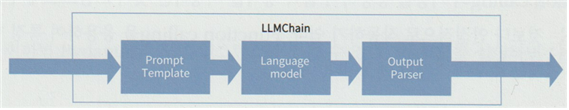

In [6]:
# 먼저 OutputParser, PromptTemplate, Language model을 준비한다.
!pip install langchain langchain-core

In [7]:
import os
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

raw_api_key = "your_api_key"
clean_api_key = raw_api_key.strip()

# 1. 원하는 데이터 구조(거푸집) 설계
class Recipe(BaseModel):
    ingredients: list[str] = Field(description="ingredients of the dish")
    steps: list[str] = Field(description="steps to make the dish")

# 2. 출력 파서 준비 : #### OutputParser
output_parser = PydanticOutputParser(pydantic_object=Recipe)

# 3. 주문서 템플릿 제작
template = """다음 요리의 레시피를 생각해 주세요.

{format_instructions}

요리: {dish}
"""
#4.  PromptTemplate
prompt = PromptTemplate(
    template=template,
    input_variables=["dish"],
    partial_variables={"format_instructions": output_parser.get_format_instructions()}
)

# 5. 구글 제미나이 비서 대기 (안전하게 clean_api_key 주입)
chat = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    google_api_key=clean_api_key
)

# 6. 무적의 컨베이어 벨트(Chain) 조립 : ##### Language model
# PromptTemplate, Language model, OutputParser를 연결한 Chain을 생성하여 일련의 흐름을 실행한다.
chain = prompt | chat | output_parser # LCEL(파이프 연산자 |) : LLMChain대신

# 7. 실행 및 결과 확인
recipe_obj = chain.invoke({"dish": "떡볶이"})

print(type(recipe_obj))  # <class '__main__.Recipe'>
print("재료 목록:", recipe_obj.ingredients)
print("조리 단계:", recipe_obj.steps)

<class '__main__.Recipe'>
재료 목록: ['떡볶이 떡 400g (쌀떡 또는 밀떡)', '사각 어묵 2~3장', '대파 1대', '양파 1/2개 (선택 사항)', '삶은 계란 2개 (선택 사항)', '멸치 육수 또는 물 500ml', '고추장 3큰술', '고춧가루 2큰술', '설탕 2큰술', '간장 1큰술', '다진 마늘 1큰술']
조리 단계: ['떡볶이 떡은 물에 30분 정도 불려 부드럽게 준비합니다. (밀떡은 불리지 않아도 됩니다.)', '어묵은 먹기 좋은 크기로 썰고, 대파는 어슷썰기, 양파는 채 썰어 준비합니다.', '큰 볼에 고추장, 고춧가루, 설탕, 간장, 다진 마늘을 넣고 잘 섞어 양념장을 만듭니다.', '냄비에 멸치 육수(또는 물)를 붓고 끓입니다.', '육수가 끓으면 불린 떡과 만들어둔 양념장을 넣고 잘 풀어주면서 끓입니다.', '떡이 부드러워지고 국물이 걸쭉해지기 시작하면 어묵, 양파, 대파를 넣습니다.', '모든 재료가 익고 국물이 자작하게 졸아들 때까지 중불에서 계속 끓입니다.', '기호에 따라 삶은 계란, 라면 사리, 치즈 등을 넣어 함께 끓여도 좋습니다.', '맛있게 졸아들면 불을 끄고 그릇에 담아 따뜻하게 즐깁니다.']


LLMChain에 OutputParser를 지정하지 않은 경우, 기본 작동으로 LLM의 출력 문자열이 그대로 Chain의 text 출력이 된다(NoOpOutputParser라는 아무것도 하지 않는 OutputParser가 사용된다).

## SimpleSequentialChain — Chain과 Chain 연결하기

Chain과 Chain을 연결하는 Chain도 있다. SimpleSequentialChain을 사용하면 Chain과 Chain을 직렬로 연결할 수 있다.<br />
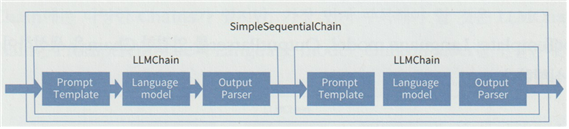

In [ ]:
!pip install -qU langchain-google-genai

In [11]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser

chat = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

cot_template = """다음 질문에 답하세요.
질문: {question}
단계별로 생각해 봅시다.
"""

cot_prompt = PromptTemplate(
    input_variables=["question"],
    template=cot_template,
)

# 3. 최신 LCEL 방식으로 체인(Chain) 구성
# LLMChain 대신 파이프라인(|) 연산자를 사용하며, 
# StrOutputParser()를 붙여 결과가 텍스트로 바로 나오게 합니다.
cot_chain = cot_prompt | chat | StrOutputParser()

# 4. 체인 실행 예시
# 이전의 cot_chain.run() 또는 cot_chain.predict() 대신 invoke()를 사용합니다.
response = cot_chain.invoke({"question": "하늘이 파란 이유는 무엇인가요?"})
print(response)

하늘이 파란 이유는 **햇빛의 산란(Scattering)** 현상 때문입니다. 특히, 대기 중의 작은 입자들이 빛을 산란시키는 **레일리 산란(Rayleigh Scattering)**이라는 원리가 핵심입니다.

단계별로 자세히 설명해 드릴게요.

---

**하늘이 파란 이유: 단계별 설명**

**1단계: 햇빛의 구성과 파장**
*   **햇빛은 백색광:** 우리가 보는 햇빛은 사실 무지개색(빨주노초파남보)의 모든 색깔이 합쳐진 백색광입니다.
*   **색깔별 파장:** 각 색깔은 서로 다른 파장을 가지고 있습니다.
    *   **짧은 파장:** 보라색, 파란색 (에너지가 높고 파동이 촘촘함)
    *   **긴 파장:** 빨간색, 주황색 (에너지가 낮고 파동이 널찍함)

**2단계: 지구 대기의 구성**
*   **작은 분자들:** 지구의 대기는 주로 질소(약 78%)와 산소(약 21%) 분자로 이루어져 있습니다. 이 분자들은 햇빛의 파장보다 훨씬 작습니다.
*   **먼지 및 수증기:** 소량의 먼지, 수증기 등 다른 입자들도 포함되어 있습니다.

**3단계: 햇빛과 대기 분자의 상호작용 (산란 현상)**
*   **빛의 산란:** 햇빛이 지구 대기로 들어오면, 대기 중의 질소, 산소 분자들과 부딪히게 됩니다. 이때 빛은 흡수되거나 반사되는 것이 아니라, 사방으로 흩어지게 되는데, 이를 **산란(Scattering)**이라고 합니다.

**4단계: 파란색 빛이 더 많이 산란되는 이유 (레일리 산란)**
*   **파장과 산란의 관계:** 대기 분자들의 크기가 햇빛의 파장보다 훨씬 작을 때, 빛의 산란 정도는 파장의 네제곱에 반비례합니다. 즉, **파장이 짧은 빛일수록 훨씬 더 많이 산란됩니다.**
*   **파란색의 우세:**
    *   보라색과 파란색은 햇빛 스펙트럼에서 가장 파장이 짧은 색깔입니다.
    *   따라서 파장이 긴 빨간색이나 주황색 빛보다 파란색 빛이 대기 분자들에 의해 약 10배 이상 더 많이 산란되어 사방으로 퍼져나갑니다.

그런 다음 입력된 텍스트를 요약하는 Chain을 생성한다.

In [12]:
summarize_template = """다음 문장을 결론만 간단히 요약하세요.

{input}
"""

summarize_prompt = PromptTemplate(
    input_variables=["input"],
    template=summarize_template,
)
summarize_chain = summarize_prompt | chat | StrOutputParser()

두 개의 Chain을 연결한 Chain을 만들어 실행해 보겠다.<br />
SimpleSequentialChain대신에 파이프라인(|) 연산자를 사용

In [15]:
cot_summarize_chain = cot_chain | summarize_chain

result = cot_summarize_chain.invoke(
    "저는 시장에 가서 사과 10개를 샀습니다. 이웃에게 2개, 수리공에게 2개를 주었습니다. 그런 다음에 사과 5개를 더 사서 1개를 먹었습니다. 남은 개수는 몇 개인가요?"
)
print(result)

남은 사과의 개수는 10개입니다.


최종적으로 요약된 간단한 답변을 얻을 수 있었다. <br />
이때 `cot_summarize_chain` 내부에서는 먼저 `cot_chain`이 실행되어 단계별로 생각한 중복된 답을 얻는다. <br />
그 답변을 입력으로 `summarize_chain`을 실행해 요약된 간단한 답변을 얻었으며, LLM을 두 번 호출함으로써 Zero-shot CoT를 사용하여 답변의 정확도를 높이면서 최종적으로 간단한 출력을 얻을 수 있었다는 것을 알 수 있다.<br /><br />

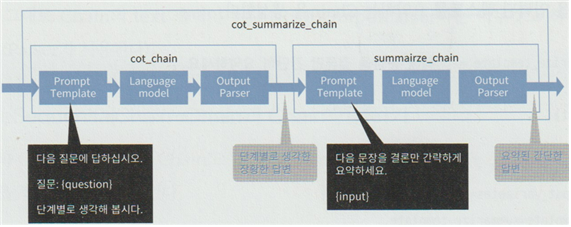

In [17]:
import os
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

# 0. 모델 선언 (가장 가벼운 제미나이 플래시 사용)
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
output_parser = StrOutputParser() # AI 답변을 순수 텍스트로 뽑아주는 파서

# =====================================================================
# 체인 1: 한글을 영어로 번역하는 체인
# =====================================================================
translate_prompt = PromptTemplate(
    template="다음 한국어 문장을 영어로 자연스럽게 번역해 주세요.\n\n문장: {korean_text}",
    input_variables=["korean_text"]
)
# 입력: {korean_text} -> 출력: 영어 번역문(텍스트)
translate_chain = translate_prompt | model | output_parser

# =====================================================================
# 체인 2: 영어 문장을 받아 요약하는 체인
# =====================================================================
# 핵심: 체인 1의 결과물(영어 텍스트)이 체인 2의 {english_text}로 들어갑니다.
summary_prompt = PromptTemplate(
    template="다음 영어 문장을 핵심만 골라 아주 짧게 한 줄로 요약해 주세요.\n\n문장: {english_text}",
    input_variables=["english_text"]
)
# 입력: {english_text} -> 출력: 영어 요약문(텍스트)
summary_chain = summary_prompt | model | output_parser

# =====================================================================
# 대망의 체인 + 체인 연결!
# =====================================================================
# 기존 체인 2의 입력 변수 이름이 {english_text}이므로, 
# 체인 1의 출력을 'english_text'라는 키에 맵핑해서 체인 2로 토스합니다.
combined_chain = translate_chain | (lambda output: {"english_text": output}) | summary_chain

# =====================================================================
# 6. 실행 및 결과 확인
# =====================================================================
input_text = "인공지능 기술은 급격하게 발전하고 있으며, 우리의 일상생활과 일하는 방식을 완전히 바꾸어 놓고 있습니다."

print("--- [시작] 원본 한글 문장 ---")
print(input_text)

# 통합 체인 가동!
final_result = combined_chain.invoke({"korean_text": input_text})

print("\n--- [최종 결과] 영어 번역 후 한 줄 요약 완료 ---")
print(final_result)

--- [시작] 원본 한글 문장 ---
인공지능 기술은 급격하게 발전하고 있으며, 우리의 일상생활과 일하는 방식을 완전히 바꾸어 놓고 있습니다.

--- [최종 결과] 영어 번역 후 한 줄 요약 완료 ---
AI의 급속한 발전이 삶과 일을 혁신한다.


LangChain에는 다양한 Chain이 준비돼 있다.<br />
사실, 요약에 사용할 수 있는 기성 체인도 있다. <br />
SimpleSequentialChain을 사용하면 다양한 Chain을 직렬로 연결할 수 있다. <br />
Chain끼리 연결하는 Chain으로는 여러 입출력을 지원하는 SequentialChain, LLM의 판단에 따라 Chain의 분기를 구현하는 LLMRouterChain 등이 있다.<br />
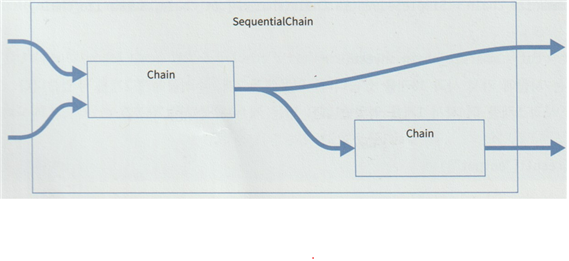<br />
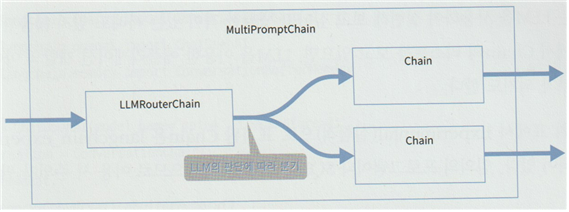

angChain은 사용 사례에 특화된 다양한 Chain도 제공한다. 여기서는 사용 사례에 특화된 체인 중 몇 가지를 소개하고자 한다.
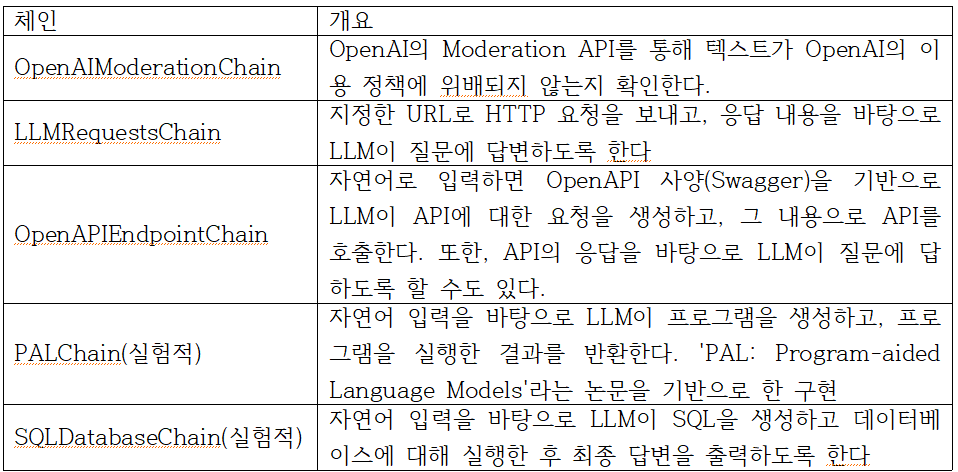

# Memory

‘Memory’는 이름 그대로 ‘기억’에 관한 기능이다.<br /> 
Chat Completions API는 스테이트리스(Stateless)로, 대화 이력을 바탕으로 응답을 얻기 위해서는 대화 이력을 요청에 포함시켜야 한다.<br />
대화 이력 저장과 관련된 편리한 기능을 제공하는 것이 바로 랭체인의 Memory다.

### InMemoryChatMessageHistory
랭체인의 Memory에는 몇 가지 종류가 있다. <br />
먼저 Memory를 사용하는 가장 간단한 예로 단순히 대화 기록을 보관하는 ChatMessageHistory를 사용해 보겠다. <br />
최신 랭체인에서는 이를 RunnableWithMessageHistory 인터페이스와 결합하여 제미나이(Gemini) 모델이 이전 대화를 기억하도록 쉽게 구현할 수 있다.

In [ ]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from langchain_google_genai import ChatGoogleGenerativeAI
# 임포트 경로를 최신 표준(langchain_core)으로 변경했습니다.
from langchain_core.chat_history import InMemoryChatMessageHistory

# 1. 제미나이 모델 및 메모리(대화 기록 버퍼) 초기화
chat = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
memory = InMemoryChatMessageHistory()

print("구글 제미나이 챗봇과 대화를 시작합니다. ('끝'을 입력하면 종료됩니다)")
print("-" * 50)

while True:
    user_message = input("You: ")
    
    if user_message == "끝":
        print("(대화 종료)")
        break
        
    # 사용자의 질문을 메모리에 추가
    memory.add_user_message(user_message)
    
    # 전체 대화 기록(메모리)을 제미나이에 전달하여 답변 유도
    # (memory.messages를 대화 형식 그대로 모델에 주입합니다)
    response = chat.invoke(memory.messages)
    ai_message = response.content
    
    # AI의 답변을 메모리에 추가
    memory.add_ai_message(ai_message)
    
    print(f"AI: {ai_message}")

이 코드에서는 Memory를 사용하여 히스토리를 기반으로 대화를 할 수 있는 ConversationChain을 사용하고 있다.<br />
사용자의 입력을 받아 LLM을 호출하고 응답을 받는 과정을 무한 반복한다<br />
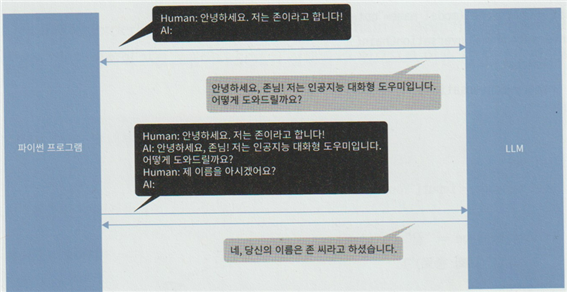

랭체인의 Memory에서 대화 기록은 기본적으로 메모리(Python의 인스턴스 변수)에 저장된다.<br />
따라서 프로세스가 중단되면 대화 기록은 유지되지 않는다.<br />
또한, 여러 프로세스 서버로 부하를 분산하는 경우나 AWS Lambda와 같은 서버리스 환경에서 실행하는 경우에는 잘 작동하지 않는다.<br />
이러한 상황에 대응하기 위해서는 대화 이력을 애플리케이션 외부에 저장해야 한다.<br /><br />

랭체인의 Memory는 여러 저장소를 지원한다.<br /> 
예를 들어, SQLite, PostgreSQL, Redis, DynamoDB, Momento와 같은 데이터베이스를 사용할 수 있다.<br />
물론 지원되지 않는 데이터베이스와 연동하는 커스터마이징도 가능하다. Momento에 대화 기록 저장을 구현한다.<br />